In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
 
print("Imports done ✓")

Imports done ✓


In [2]:
train = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\train.csv')
test  = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\test.csv')
 
X_train = train.drop(columns=['SalePrice'])
X_test  = test.drop(columns=['SalePrice'])
y_train = train['SalePrice'].values
y_test  = test['SalePrice'].values
 
print(f"X_train : {X_train.shape}")
 
# Baseline from Phase 5 — plain Linear Regression, no penalty
baseline = LinearRegression()
baseline.fit(X_train, y_train)
r2_baseline   = r2_score(y_test, baseline.predict(X_test))
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test)))
print(f"Baseline (no regularisation) R² : {r2_baseline:.4f}")

X_train : (2341, 188)
Baseline (no regularisation) R² : 0.9523


In [3]:
#  Ridge penalty term added to the cost function:
#    Cost = MSE + α * Σ(βᵢ²)
#
#  Squaring the coefficients means LARGE coefficients get
#  punished heavily, small ones barely at all. This shrinks
#  every coefficient toward 0 — but never exactly to 0.
#  Good for handling multicollinearity because correlated
#  features end up sharing the "blame" more evenly.
# ────────────────────────────────────────────────────────────────
 
# GridSearchCV tries every alpha value and picks the best one
# using cross-validation (splits train data into 5 folds internally)
ridge_alphas = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]}
 
ridge_grid = GridSearchCV(
    estimator = Ridge(),
    param_grid= ridge_alphas,
    cv        = 5,                 # 5-fold cross-validation
    scoring   = 'r2'
)
ridge_grid.fit(X_train, y_train)
 
best_ridge_alpha = ridge_grid.best_params_['alpha']
ridge_best       = ridge_grid.best_estimator_
 
r2_ridge   = r2_score(y_test, ridge_best.predict(X_test))
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_best.predict(X_test)))
 
print("── Ridge Regression ─────────────────────────")
print(f"  Best alpha : {best_ridge_alpha}")
print(f"  Test RMSE  : {rmse_ridge:.4f}")
print(f"  Test R²    : {r2_ridge:.4f}")
 

── Ridge Regression ─────────────────────────
  Best alpha : 10
  Test RMSE  : 0.0920
  Test R²    : 0.9529


In [4]:
#
#  Lasso penalty term:
#    Cost = MSE + α * Σ|βᵢ|
#
#  Using absolute value instead of squaring has a special effect:
#  it can push weak coefficients all the way to EXACTLY 0,
#  completely removing that feature from the model.
#  This makes Lasso do automatic feature selection.
# ────────────────────────────────────────────────────────────────
 
lasso_alphas = {'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]}
 
lasso_grid = GridSearchCV(
    estimator = Lasso(max_iter=10000),
    param_grid= lasso_alphas,
    cv        = 5,
    scoring   = 'r2'
)
lasso_grid.fit(X_train, y_train)
 
best_lasso_alpha = lasso_grid.best_params_['alpha']
lasso_best       = lasso_grid.best_estimator_
 
r2_lasso   = r2_score(y_test, lasso_best.predict(X_test))
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_best.predict(X_test)))
 
# Count how many features survived (non-zero coefficient)
n_features_kept = np.sum(lasso_best.coef_ != 0)
 
print("── Lasso Regression ─────────────────────────")
print(f"  Best alpha        : {best_lasso_alpha}")
print(f"  Test RMSE          : {rmse_lasso:.4f}")
print(f"  Test R²            : {r2_lasso:.4f}")
print(f"  Features kept       : {n_features_kept} out of {X_train.shape[1]}")
print(f"  Features zeroed out : {X_train.shape[1] - n_features_kept}")
 

── Lasso Regression ─────────────────────────
  Best alpha        : 0.0001
  Test RMSE          : 0.0921
  Test R²            : 0.9527
  Features kept       : 151 out of 188
  Features zeroed out : 37


In [5]:
#
#  ElasticNet blends Ridge and Lasso using a mix ratio (l1_ratio):
#    Cost = MSE + α * [ l1_ratio * Σ|βᵢ|  +  (1-l1_ratio) * Σ(βᵢ²) ]
#
#  l1_ratio = 1.0  → pure Lasso
#  l1_ratio = 0.0  → pure Ridge
#  l1_ratio = 0.5  → equal mix of both
#
#  Useful when you want SOME feature selection (like Lasso)
#  but also want stability with correlated features (like Ridge).
# ────────────────────────────────────────────────────────────────
 
elastic_params = {
    'alpha':    [0.0001, 0.001, 0.01, 0.1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
 
elastic_grid = GridSearchCV(
    estimator = ElasticNet(max_iter=10000),
    param_grid= elastic_params,
    cv        = 5,
    scoring   = 'r2'
)
elastic_grid.fit(X_train, y_train)
 
best_elastic_params = elastic_grid.best_params_
elastic_best         = elastic_grid.best_estimator_
 
r2_elastic   = r2_score(y_test, elastic_best.predict(X_test))
rmse_elastic = np.sqrt(mean_squared_error(y_test, elastic_best.predict(X_test)))
n_features_elastic = np.sum(elastic_best.coef_ != 0)
 
print("── ElasticNet ────────────────────────────────")
print(f"  Best params : {best_elastic_params}")
print(f"  Test RMSE    : {rmse_elastic:.4f}")
print(f"  Test R²      : {r2_elastic:.4f}")
print(f"  Features kept: {n_features_elastic} out of {X_train.shape[1]}")
 
 

── ElasticNet ────────────────────────────────
  Best params : {'alpha': 0.001, 'l1_ratio': 0.1}
  Test RMSE    : 0.0920
  Test R²      : 0.9529
  Features kept: 147 out of 188


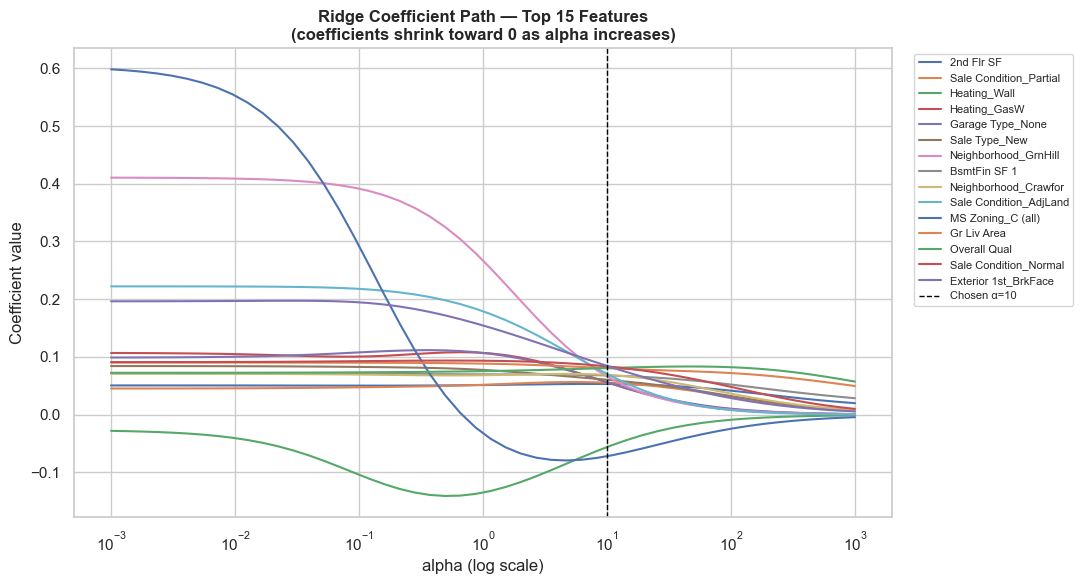

In [6]:
# Shows HOW coefficients shrink as alpha increases.
# Watch the lines converge toward 0 as alpha grows — that's
# regularisation actively "calming down" the model.
 
alphas_range = np.logspace(-3, 3, 50)   # 0.001 to 1000, 50 steps
ridge_coefs  = []
 
for a in alphas_range:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    ridge_coefs.append(r.coef_)
 
ridge_coefs = np.array(ridge_coefs)
 
plt.figure(figsize=(11, 6))
# plot only top 15 features by their final coefficient size (keeps plot readable)
top_idx = np.argsort(np.abs(ridge_best.coef_))[-15:]
for idx in top_idx:
    plt.plot(alphas_range, ridge_coefs[:, idx], label=X_train.columns[idx])
 
plt.xscale('log')
plt.axvline(best_ridge_alpha, color='black', linestyle='--', linewidth=1,
            label=f'Chosen α={best_ridge_alpha}')
plt.xlabel('alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('Ridge Coefficient Path — Top 15 Features\n(coefficients shrink toward 0 as alpha increases)',
          fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\21_ridge_coef_path.png',
            dpi=150, bbox_inches='tight')
plt.show()
 

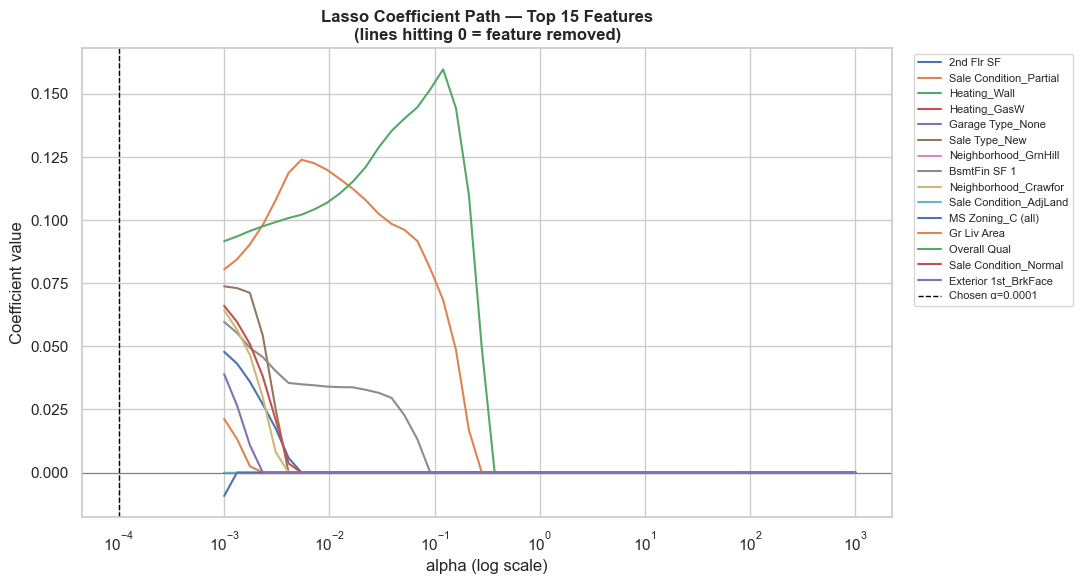

In [7]:
# Same idea, but watch lines hit EXACTLY 0 and stay there —
# that's a feature being completely removed from the model.
 
lasso_coefs = []
for a in alphas_range:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_train, y_train)
    lasso_coefs.append(l.coef_)
 
lasso_coefs = np.array(lasso_coefs)
 
plt.figure(figsize=(11, 6))
for idx in top_idx:   # same top 15 features as Ridge plot, for comparison
    plt.plot(alphas_range, lasso_coefs[:, idx], label=X_train.columns[idx])
 
plt.xscale('log')
plt.axvline(best_lasso_alpha, color='black', linestyle='--', linewidth=1,
            label=f'Chosen α={best_lasso_alpha}')
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Coefficient Path — Top 15 Features\n(lines hitting 0 = feature removed)',
          fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\22_lasso_coef_path.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
 

In [8]:
print("=" * 62)
print("          REGULARISATION — FINAL COMPARISON")
print("=" * 62)
print(f"{'Model':<28} {'Features':>10} {'RMSE':>8} {'R²':>8}")
print("-" * 62)
print(f"{'Linear Regression (base)':<28} {X_train.shape[1]:>10} {rmse_baseline:>8.4f} {r2_baseline:>8.4f}")
print(f"{'Ridge (α=' + str(best_ridge_alpha) + ')':<28} {X_train.shape[1]:>10} {rmse_ridge:>8.4f} {r2_ridge:>8.4f}")
print(f"{'Lasso (α=' + str(best_lasso_alpha) + ')':<28} {n_features_kept:>10} {rmse_lasso:>8.4f} {r2_lasso:>8.4f}")
print(f"{'ElasticNet':<28} {n_features_elastic:>10} {rmse_elastic:>8.4f} {r2_elastic:>8.4f}")
print("=" * 62)
 
best_model_name = max(
    [('Ridge', r2_ridge), ('Lasso', r2_lasso), ('ElasticNet', r2_elastic)],
    key=lambda x: x[1]
)[0]
print(f"\nBest performing regularised model : {best_model_name}")
print(f"\nWhy this matters:")
print(f"  → Ridge keeps ALL features but makes coefficients stable")
print(f"    (fixes the VIF/multicollinearity problem from Phase 5)")
print(f"  → Lasso automatically removed {X_train.shape[1]-n_features_kept} features —")
print(f"    a smarter, data-driven version of what we tried manually in Phase 7")
print(f"  → Next: Phase 9 — full evaluation with cross-validation")

          REGULARISATION — FINAL COMPARISON
Model                          Features     RMSE       R²
--------------------------------------------------------------
Linear Regression (base)            188   0.0926   0.9523
Ridge (α=10)                        188   0.0920   0.9529
Lasso (α=0.0001)                    151   0.0921   0.9527
ElasticNet                          147   0.0920   0.9529

Best performing regularised model : ElasticNet

Why this matters:
  → Ridge keeps ALL features but makes coefficients stable
    (fixes the VIF/multicollinearity problem from Phase 5)
  → Lasso automatically removed 37 features —
    a smarter, data-driven version of what we tried manually in Phase 7
  → Next: Phase 9 — full evaluation with cross-validation
